In [24]:
import h5py
import numpy as np
import spacy
from scipy.special import softmax
from utils import text_utils
import pandas as pd

nlp = spacy.load("en_core_web_sm")

# heuristic: VERB -> no_gap, everything else -> gap
GAP_POS = {'VERB'}
SUBJECT_POS = {'DET', 'PRON'}

def get_gap_probabilities(sentence_starts, hdf5_path, n_samples=100):
    """
    For each sentence start, computes the probability of gap vs no_gap
    by sampling next tokens from an lm-zoo hdf5 file and applying the POS heuristic.
    
    Args:
        sentence_starts: dict of {original_idx: {sentence_start, condition, levels_of_embedding}}
        hdf5_path: path to hdf5 file of next-token predictions
        n_samples: number of tokens to sample from the distribution
    
    Returns:
        same dict with added keys: p_no_gap, p_gap, predicted
    """
    
    with h5py.File(hdf5_path, 'r') as f:
        vocab = [token.decode('utf-8') for token in f['vocabulary'][:]]
        original_indices = list(sentence_starts.keys())
        
        for seq_idx, original_idx in enumerate(original_indices):
            entry = sentence_starts[original_idx]
            
            sent = f['sentence'][str(seq_idx)]
            log_probs = sent['predictions'][-1]
            probs = softmax(log_probs).astype(float)
            probs = probs / probs.sum()
            
            sampled_indices = np.random.choice(len(probs), size=n_samples, p=probs)
            
            gap_count = 0
            no_gap_count = 0
            subject_count = 0
            
            for token_idx in sampled_indices:
                token = vocab[token_idx].replace('Ġ', ' ').strip()
                doc = nlp(entry['sentence_start'] + ' ' + token)
                pos = doc[-1].pos_
                
                if pos in GAP_POS:
                    gap_count += 1
                else:
                    no_gap_count += 1
                    
                if pos in SUBJECT_POS:
                    subject_count += 1
            
            entry['gap_count'] = gap_count
            entry['no_gap_count'] = no_gap_count
            entry['subject_count'] = subject_count
    
    return sentence_starts

In [25]:
def compute_and_show_results(path):
    sentence_starts = text_utils.build_sentence_starts_for_sampling(
        "../data/stimuli/pilot_subject_gap.csv", gap_type="subject"
    )
    sentence_starts = get_gap_probabilities(sentence_starts, path)
    rows = []

    for sentence_id, entry in sentence_starts.items():
        expected  = 'no_gap' if entry['condition'].endswith('no_gap') else 'gap'
        n_samples = entry['gap_count'] + entry['no_gap_count']

        for _ in range(entry['gap_count']):
            rows.append({
                'sentence_id':     sentence_id,
                'condition':       entry['condition'],
                'embedding_level': entry['levels_of_embedding'],
                'expected':        expected,
                'predicted':       'gap',
            })
        for _ in range(entry['no_gap_count']):
            rows.append({
                'sentence_id':     sentence_id,
                'condition':       entry['condition'],
                'embedding_level': entry['levels_of_embedding'],
                'expected':        expected,
                'predicted':       'no_gap',
            })

    df_results = pd.DataFrame(rows)
    df_results['correct'] = df_results['expected'] == df_results['predicted']
    df_results['error']   = ~df_results['correct']

    by_condition     = df_results.groupby('condition')['error'].mean().round(3)
    by_embedding     = df_results.groupby('embedding_level')['error'].mean().round(3)
    by_condition_emb = df_results.groupby(['condition', 'embedding_level'])['error'].mean().round(3).unstack()

    # subject % per sentence aggregated
    subject_pcts = {
        sentence_id: round(entry['subject_count'] / (entry['gap_count'] + entry['no_gap_count']) * 100, 1)
        for sentence_id, entry in sentence_starts.items()
    }
    subject_pct_by_condition = {}
    for sentence_id, entry in sentence_starts.items():
        cond = entry['condition']
        if cond not in subject_pct_by_condition:
            subject_pct_by_condition[cond] = []
        subject_pct_by_condition[cond].append(subject_pcts[sentence_id])
    subject_pct_by_condition_mean = {
        cond: round(np.mean(pcts), 1)
        for cond, pcts in subject_pct_by_condition.items()
    }

    print("\n=== MEAN ERROR RATE BY CONDITION ===")
    print(by_condition)
    print("\n=== MEAN ERROR RATE BY EMBEDDING LEVEL ===")
    print(by_embedding)
    print("\n=== MEAN ERROR RATE BY CONDITION x EMBEDDING LEVEL ===")
    print(by_condition_emb)

    print("\n=== % SUBJECT-PREDICTING SAMPLES (aggregated) ===")
    overall_subject_pct = round(
        np.mean(list(subject_pcts.values())), 1
    )
    print(f"  overall: {overall_subject_pct}%")
    print("\n=== % SUBJECT-PREDICTING SAMPLES BY CONDITION ===")
    for cond, pct in sorted(subject_pct_by_condition_mean.items()):
        print(f"  {cond}: {pct}%")

    tp = ((df_results['expected'] == 'gap')    & (df_results['predicted'] == 'gap')).sum()
    fp = ((df_results['expected'] == 'no_gap') & (df_results['predicted'] == 'gap')).sum()
    tn = ((df_results['expected'] == 'no_gap') & (df_results['predicted'] == 'no_gap')).sum()
    fn = ((df_results['expected'] == 'gap')    & (df_results['predicted'] == 'no_gap')).sum()

    confusion = pd.DataFrame(
        [[tp, fn], [fp, tn]],
        index   = pd.Index(['predicted gap',    'predicted no_gap'], name=''),
        columns = pd.Index(['actual gap', 'actual no_gap'],          name='')
    )

    print("\n=== CONFUSION MATRIX (n=100 samples per sentence) ===")
    print(confusion)
    print(f"\n  precision : {tp / (tp + fp):.3f}  (of predicted gaps, how many were real)")
    print(f"  recall    : {tp / (tp + fn):.3f}  (of real gaps, how many were predicted)")
    print(f"  accuracy  : {(tp + tn) / len(df_results):.3f}")

    return {
        'df':                        df_results,
        'by_condition':              by_condition,
        'by_embedding':              by_embedding,
        'by_condition_emb':          by_condition_emb,
        'confusion':                 confusion,
        'subject_pcts':              subject_pcts,
        'subject_pct_by_condition':  subject_pct_by_condition_mean,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'precision': tp / (tp + fp),
        'recall':    tp / (tp + fn),
        'accuracy':  (tp + tn) / len(df_results),
    }

## Results for gpt2

In [27]:
gpt2_results = compute_and_show_results("../data/model_outputs/predictions/gpt2_pilot_subject_gap.hdf5")


=== MEAN ERROR RATE BY CONDITION ===
condition
+wh_gap       0.891
-wh_no_gap    0.012
Name: error, dtype: float64

=== MEAN ERROR RATE BY EMBEDDING LEVEL ===
embedding_level
0    0.377
1    0.482
2    0.468
3    0.480
Name: error, dtype: float64

=== MEAN ERROR RATE BY CONDITION x EMBEDDING LEVEL ===
embedding_level      0      1      2     3
condition                                 
+wh_gap          0.720  0.950  0.933  0.96
-wh_no_gap       0.033  0.013  0.003  0.00

=== % SUBJECT-PREDICTING SAMPLES (aggregated) ===
  overall: 42.2%

=== % SUBJECT-PREDICTING SAMPLES BY CONDITION ===
  +wh_gap: 30.7%
  -wh_no_gap: 53.7%

=== CONFUSION MATRIX (n=100 samples per sentence) ===
                  actual gap  actual no_gap
                                           
predicted gap            131           1069
predicted no_gap          15           1185

  precision : 0.897  (of predicted gaps, how many were real)
  recall    : 0.109  (of real gaps, how many were predicted)
  accuracy  : 

## Results for grnn

In [28]:
grnn_results = compute_and_show_results("../data/model_outputs/predictions/grnn_pilot_subject_gap.hdf5")


=== MEAN ERROR RATE BY CONDITION ===
condition
+wh_gap       0.875
-wh_no_gap    0.008
Name: error, dtype: float64

=== MEAN ERROR RATE BY EMBEDDING LEVEL ===
embedding_level
0    0.297
1    0.483
2    0.500
3    0.485
Name: error, dtype: float64

=== MEAN ERROR RATE BY CONDITION x EMBEDDING LEVEL ===
embedding_level      0      1     2      3
condition                                 
+wh_gap          0.580  0.967  0.99  0.963
-wh_no_gap       0.013  0.000  0.01  0.007

=== % SUBJECT-PREDICTING SAMPLES (aggregated) ===
  overall: 29.7%

=== % SUBJECT-PREDICTING SAMPLES BY CONDITION ===
  +wh_gap: 16.5%
  -wh_no_gap: 42.9%

=== CONFUSION MATRIX (n=100 samples per sentence) ===
                  actual gap  actual no_gap
                                           
predicted gap            150           1050
predicted no_gap           9           1191

  precision : 0.943  (of predicted gaps, how many were real)
  recall    : 0.125  (of real gaps, how many were predicted)
  accuracy  : 

## Results for ngram
Ngram is a very simple model that does not have a mechanism for long distance dependencies, it only considers the previous 5 tokens. As a result the 50% accuracy is expected.

In [29]:
ngram_results = compute_and_show_results("../data/model_outputs/predictions/ngram_pilot_subject_gap.hdf5")


=== MEAN ERROR RATE BY CONDITION ===
condition
+wh_gap       0.708
-wh_no_gap    0.173
Name: error, dtype: float64

=== MEAN ERROR RATE BY EMBEDDING LEVEL ===
embedding_level
0    0.237
1    0.510
2    0.533
3    0.483
Name: error, dtype: float64

=== MEAN ERROR RATE BY CONDITION x EMBEDDING LEVEL ===
embedding_level      0      1      2      3
condition                                  
+wh_gap          0.223  0.863  0.873  0.873
-wh_no_gap       0.250  0.157  0.193  0.093

=== % SUBJECT-PREDICTING SAMPLES (aggregated) ===
  overall: 0.2%

=== % SUBJECT-PREDICTING SAMPLES BY CONDITION ===
  +wh_gap: 0.2%
  -wh_no_gap: 0.1%

=== CONFUSION MATRIX (n=100 samples per sentence) ===
                  actual gap  actual no_gap
                                           
predicted gap            350            850
predicted no_gap         208            992

  precision : 0.627  (of predicted gaps, how many were real)
  recall    : 0.292  (of real gaps, how many were predicted)
  accuracy  :

## Visualisations

### error rate by model x condition

In [30]:
import matplotlib.pyplot as plt

def plot_error_rate_by_model_and_condition(results_dict):
    models     = list(results_dict.keys())
    conditions = sorted(next(iter(results_dict.values()))['by_condition'].index)

    n_models     = len(models)
    n_conditions = len(conditions)
    x            = np.arange(n_conditions)
    width        = 0.5 / n_models
    offsets      = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width
    colors       = ['#5bbcd6', '#f98400', '#00a08a', '#ff0000'][:n_models]

    fig, ax = plt.subplots(figsize=(7, 5))

    for i, model in enumerate(models):
        error_rates = [results_dict[model]['by_condition'].get(c, np.nan) for c in conditions]
        bars = ax.bar(x + offsets[i], error_rates, width, label=model, color=colors[i], alpha=0.85)

        for bar, rate in zip(bars, error_rates):
            if not np.isnan(rate):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    model,
                    ha='left', va='bottom',
                    fontsize=9, rotation=45,
                    color='black'
                )

    ax.set_xticks(x)
    ax.set_xticklabels(conditions, rotation=15, ha='right')
    ax.set_ylabel('Mean Error Rate')
    ax.set_xlabel('Condition')
    ax.set_title('Mean Error Rate by Model and Condition')
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

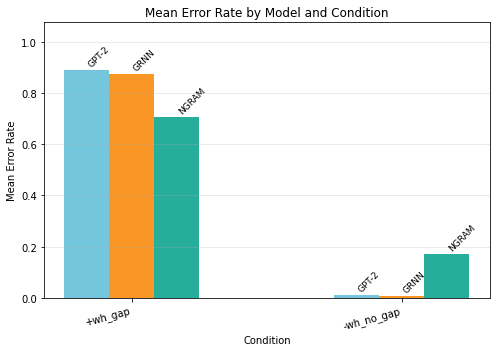

In [31]:
plot_error_rate_by_model_and_condition({
    'GPT-2': gpt2_results,
    'GRNN':  grnn_results,
    'NGRAM':ngram_results
})

### error rate by model x embedding level

In [35]:


def plot_error_rate_by_model_and_embedding(results_dict):
    """
    Plots mean error rate by model and embedding level as a grouped bar chart.

    Args:
        results_dict: dict of {model_name: results} where results is the
                      dict returned by compute_and_show_results
    """
    models           = list(results_dict.keys())
    embedding_levels = sorted(next(iter(results_dict.values()))['by_embedding'].index)

    n_models         = len(models)
    n_levels         = len(embedding_levels)
    x                = np.arange(n_levels)
    width            = 0.5 / n_models
    offsets          = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width
    colors           = ['#5bbcd6', '#f98400', '#00a08a', '#ff0000'][:n_models]

    fig, ax = plt.subplots(figsize=(10, 7))

    for i, model in enumerate(models):
        error_rates = [results_dict[model]['by_embedding'].get(lvl, np.nan) for lvl in embedding_levels]
        bars = ax.bar(x + offsets[i], error_rates, width, color=colors[i], alpha=0.85)

        for bar, rate in zip(bars, error_rates):
            if not np.isnan(rate):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    model,
                    ha='left', va='bottom',
                    fontsize=9, rotation=45,
                    color='black'
                )

    ax.set_xticks(x)
    ax.set_xticklabels([f'embedding {l}' for l in embedding_levels])
    ax.set_ylabel('Mean Error Rate')
    ax.set_xlabel('Embedding Level')
    ax.set_title('Mean Error Rate by Model and Embedding Level')
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    ax.legend().set_visible(False)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.savefig('../data/images/subject_sampling_accuracy.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


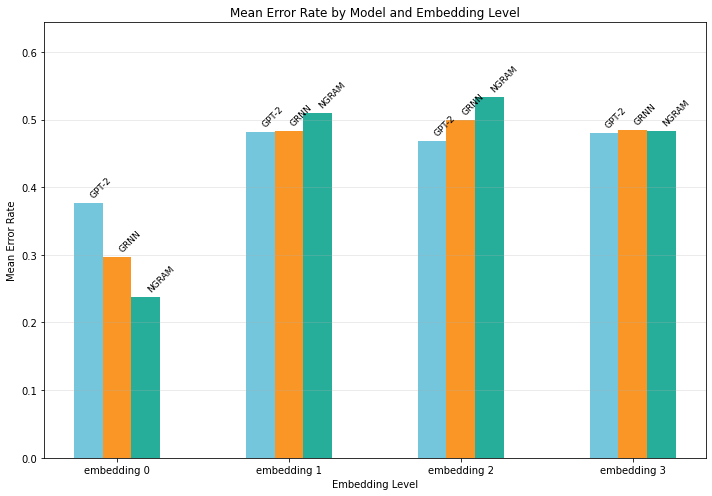

In [37]:
plot_error_rate_by_model_and_embedding({
    'GPT-2': gpt2_results,
    'GRNN':  grnn_results,
    'NGRAM': ngram_results
})